In [64]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
from astroML.linear_model import PolynomialRegression
from astroML.linear_model import BasisFunctionRegression
from astroML.linear_model import NadarayaWatson
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate

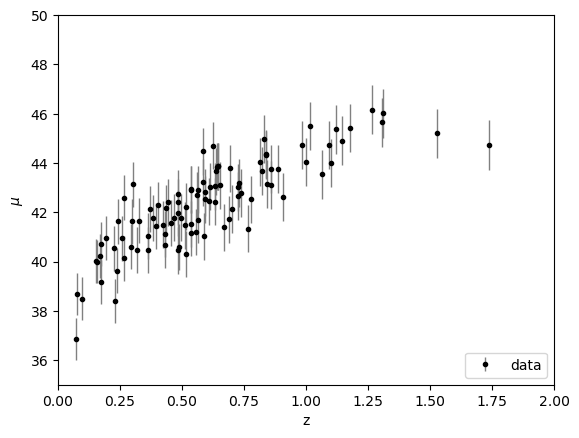

In [3]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [5]:
print(dmu)

[0.91862497 0.95818624 0.94340343 0.97222794 0.97171179 0.92819662
 0.92860378 0.97385018 0.9966678  0.98218018 0.93649091 0.948558
 0.96318467 0.9656542  0.93760835 0.95334492 0.94872528 0.86485225
 0.97103496 0.98306194 0.93712847 0.95764923 0.89710554 0.93748105
 0.99104229 0.96054687 0.93997207 0.97255426 0.93265984 0.95389152
 0.98131431 0.94327408 0.97387777 0.91153822 0.96493354 0.96496076
 0.92210777 0.98951197 0.94376982 0.98691576 0.89231065 0.91764268
 0.88762944 0.96247275 0.95599473 0.95113453 0.88588283 0.95336368
 0.93388642 0.94871596 0.90572161 0.95699473 0.95372094 0.85295833
 0.95781273 0.98736141 0.97272887 1.01211963 0.99684655 0.97286954
 0.92951505 0.95841129 0.94671347 0.91917738 0.93867591 0.89019692
 0.94455508 1.00520951 0.9080577  0.90719541 0.96790571 0.95541351
 0.94618927 0.90474131 0.92335956 0.98549227 0.94164366 0.95133629
 0.85158066 0.93107145 0.943334   0.95738992 0.98835882 0.95847705
 0.96508125 0.91252869 0.96857855 0.97688395 0.95911907 0.943451

### linear regression

In [9]:
print(z_sample.shape)
z_fit = z_sample.reshape(-1,1)
print(z_fit.shape)

(100,)
(100, 1)


In [13]:
lin_reg = LinearRegression()
lin_reg.fit(z_fit, mu_sample, dmu)

LinearRegression()

In [27]:
theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_
X_grid = np.linspace(0, 2, 100).reshape(-1,1)
y_pred = lin_reg.predict(X_grid)

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_16780\3535639619.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("r$\mu$")


(35.0, 50.0)

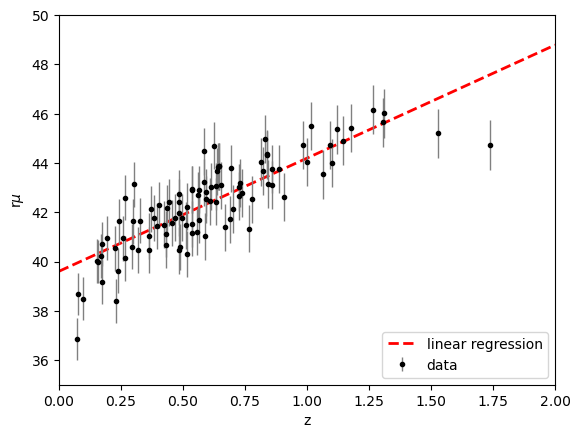

In [29]:
plt.plot(X_grid, y_pred, "r--", linewidth=2, label="linear regression")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel(r"z")
plt.ylabel("r$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### polinomial regression

(35.0, 50.0)

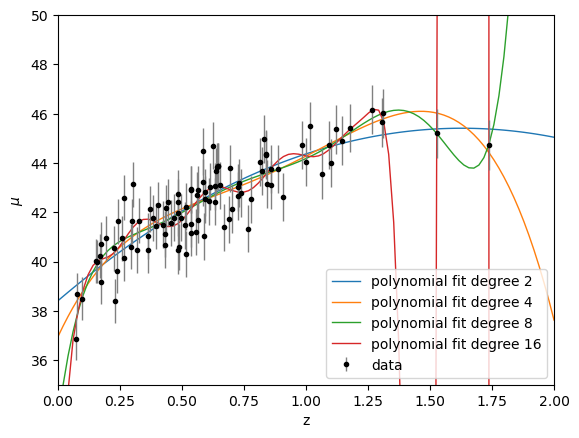

In [33]:
poli_index = [2,4,8,16]

for i in poli_index:
    model = PolynomialRegression(i)
    model.fit(z_fit, mu_sample, dmu)
    y_pred_poli = model.predict(X_grid)
    plt.plot(X_grid, y_pred_poli, linewidth=1, label=f"polynomial fit degree {i}")

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

based on my intuition degree four and degree 8 seems the better: degree two underfitting and degree 16 overfitting.

### basis function regression

In [35]:
# widths of these Gaussians
X_gridtest = np.linspace(0,2,10).reshape(-1,1)
sigma_test = 2.0/10.0
print(sigma_test)

model_basis_regression = BasisFunctionRegression('gaussian', mu=X_gridtest, sigma=sigma_test)
model_basis_regression.fit(z_fit, mu_sample, dmu)

y_pred_basis_regression = model_basis_regression.predict(X_grid)

0.2


(35.0, 50.0)

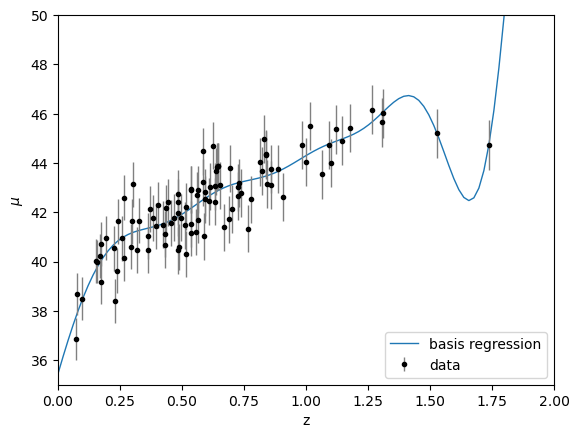

In [37]:
plt.plot(X_grid, y_pred_basis_regression, linewidth=1, label="basis regression")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### Kernel regression

In [39]:
model_Watson = NadarayaWatson(kernel='gaussian', h=0.05)
model_Watson.fit(z_fit, mu_sample)
y_pred_Watson = model_Watson.predict(X_grid)

(35.0, 50.0)

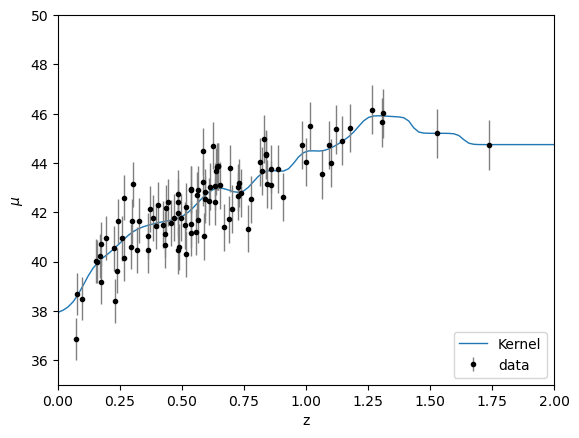

In [41]:
plt.plot(X_grid, y_pred_Watson, linewidth=1, label="Kernel")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### creation of train and validation set

In [87]:
z_train, z_validation, mu_train, mu_validation = train_test_split(z_sample, np.array([mu_sample,dmu]).T, test_size=0.25, random_state=42) 

In [117]:
print(z_train.shape)
print(mu_train.shape)
print(z_train)

(75,)
(75, 2)
[0.58487846 0.17527352 0.5639978  0.99995019 0.51079739 0.53429221
 0.58508523 0.2648093  0.39392919 1.26550558 0.36113938 0.49515162
 0.16774019 0.72698343 0.5359888  0.53589418 0.72661499 0.8573685
 0.53556302 0.8370468  1.01633991 0.63108663 0.66951722 0.51591245
 0.73642792 1.17731844 0.83200371 0.09800896 0.48779261 1.30588524
 0.07346547 0.36402348 0.44245798 0.32043128 0.48484157 0.83975753
 0.68823025 0.63611004 0.69403869 0.23081645 1.52882264 0.1532864
 0.24200318 0.64328593 0.88597706 0.38195931 0.29329624 1.31019458
 0.40340699 0.17190086 1.7374507  1.06289941 0.8578064  0.51771284
 0.84194741 0.3023762  0.72861606 1.14459622 0.59093132 0.64057897
 0.58903611 0.63416305 0.48439381 0.43240289 0.90683335 0.5912054
 0.32844018 0.77756445 1.12054039 0.42947624 0.37055496 0.60809653
 0.43346403 0.55672118 0.62642515]


In [95]:
# plot errors as a function of polynomial degree d
d = np.arange(0, 25)
training_err = np.zeros(d.shape)
val_err = np.zeros(d.shape)
d.shape

(25,)

C:\Users\User\AppData\Local\Temp\ipykernel_16780\64227726.py:3: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(z_sample, mu_sample, d[i])
C:\Users\User\AppData\Local\Temp\ipykernel_16780\64227726.py:3: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(z_sample, mu_sample, d[i])
C:\Users\User\AppData\Local\Temp\ipykernel_16780\64227726.py:3: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(z_sample, mu_sample, d[i])
C:\Users\User\AppData\Local\Temp\ipykernel_16780\64227726.py:3: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(z_sample, mu_sample, d[i])
C:\Users\User\AppData\Local\Temp\ipykernel_16780\64227726.py:3: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(z_sample, mu_sample, d[i])
C:\Users\User\AppData\Local\Temp\ipykernel_16780\64227726.py:3: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(z_sample, mu_sample, d[i])
C:\Users\User\AppData\Local\Temp\ipykernel_16780\64227726.py:3: RankWa

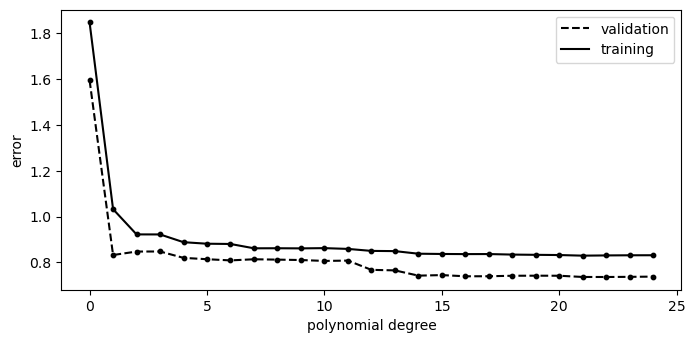

In [112]:
fig = plt.figure(figsize=(8, 8))
for i in range(len(d)):
    p = np.polyfit(z_sample, mu_sample, d[i])
    training_err[i] = np.sqrt(np.sum((np.polyval(p, z_train) - mu_train[:, 0]) ** 2)
                              / len(mu_train))
    val_err[i] = np.sqrt(np.sum((np.polyval(p, z_validation) - mu_validation[:, 0]) ** 2)
                              / len(mu_validation))


ax = fig.add_subplot(211)
ax.plot(d,val_err, "--k", label='validation')
ax.plot(d, training_err, "-k", label='training')
ax.scatter(d, val_err, s=10, color="black")
ax.scatter(d, training_err, s=10, color="black")

ax.set_xlabel('polynomial degree')
ax.set_ylabel("error")
ax.legend()

for low order both training and cv error are high, we are underfitting data. 
for high order the training error becomes small (by def) but the validation error should be large... this is not really our case. 

### trying with learing curves...

fig = plt.figure(figsize=(8, 8))
N_point = np.arange(2, 76, 2)

for deg,n in zip(d, N_point):
    p = np.polyfit(z_sample[, mu_sample, d[i])
    training_err[i] = np.sqrt(np.sum((np.polyval(p, z_train) - mu_train[:, 0]) ** 2)
                              / len(mu_train))
    val_err[i] = np.sqrt(np.sum((np.polyval(p, z_validation) - mu_validation[:, 0]) ** 2)
                              / len(mu_validation))


ax = fig.add_subplot(211)
ax.plot(d,val_err, "--k", label='validation')
ax.plot(d, training_err, "-k", label='training')
ax.scatter(d, val_err, s=10, color="black")
ax.scatter(d, training_err, s=10, color="black")

ax.set_xlabel('polynomial degree')
ax.set_ylabel("error")
ax.legend()